# SVM

In [1]:
# import lib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset

data = pd.read_csv("loan_approval.csv")
data

,Age,Gender,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Loan_Approved
0,59,Male,Graduate,Business,110373,674771,616,Medium,No
1,49,Female,Postgraduate,Salaried,103362,573886,801,Low,Yes
2,35,Female,12th,Business,110517,583884,641,Medium,No
3,28,Male,12th,Salaried,85450,284627,538,High,Yes
4,41,Female,Graduate,Self-Employed,30382,681827,751,Low,No
...,...,...,...,...,...,...,...,...,...
495,32,Female,Postgraduate,Salaried,74341,899710,544,High,No
496,29,Male,Postgraduate,Business,32087,629365,560,High,No
497,27,Female,Graduate,Salaried,43762,162782,582,High,No
498,48,Male,Postgraduate,Business,135812,677220,622,Medium,Yes


### basic checks on data

In [3]:
# column

data.columns

Index(['Age', 'Gender', 'Education', 'Employment_Type', 'Income',
       'Loan_Amount', 'Credit_Score', 'Credit_Risk', 'Loan_Approved'],
      dtype='object')

In [4]:
# shape

data.shape

(500, 9)

In [5]:
# data type

data.dtypes

Age                 int64
Gender             object
Education          object
Employment_Type    object
Income              int64
Loan_Amount         int64
Credit_Score        int64
Credit_Risk        object
Loan_Approved      object
dtype: object

In [6]:
# info

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              500 non-null    int64 
 1   Gender           500 non-null    object
 2   Education        500 non-null    object
 3   Employment_Type  500 non-null    object
 4   Income           500 non-null    int64 
 5   Loan_Amount      500 non-null    int64 
 6   Credit_Score     500 non-null    int64 
 7   Credit_Risk      500 non-null    object
 8   Loan_Approved    500 non-null    object
dtypes: int64(4), object(5)
memory usage: 35.3+ KB


In [7]:
# null values

data.isnull().sum()

Age                0
Gender             0
Education          0
Employment_Type    0
Income             0
Loan_Amount        0
Credit_Score       0
Credit_Risk        0
Loan_Approved      0
dtype: int64

In [8]:
# statistical analysis

data.describe()

,Age,Income,Loan_Amount,Credit_Score
count,500.000000,500.00000,500.000000,500.000000
mean,41.436000,84360.13000,513756.430000,676.458000
std,11.656142,35892.87942,269488.104487,100.816706
min,21.000000,20163.00000,56530.000000,500.000000
25%,32.000000,52680.75000,285445.250000,590.000000
50%,43.000000,82297.50000,519272.000000,670.500000
75%,52.000000,114572.25000,726075.500000,766.000000
max,60.000000,149226.00000,997594.000000,849.000000


In [9]:
# for categorial column

data.describe(include="object")

,Gender,Education,Employment_Type,Credit_Risk,Loan_Approved
count,500,500,500,500,500
unique,2,3,3,3,2
top,Male,Graduate,Salaried,Low,No
freq,265,253,273,212,328


In [10]:
# to check duplicate values

data.duplicated().sum()

np.int64(0)

In [11]:
# to fetch top rec

data.head()

,Age,Gender,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Loan_Approved
0,59,Male,Graduate,Business,110373,674771,616,Medium,No
1,49,Female,Postgraduate,Salaried,103362,573886,801,Low,Yes
2,35,Female,12th,Business,110517,583884,641,Medium,No
3,28,Male,12th,Salaried,85450,284627,538,High,Yes
4,41,Female,Graduate,Self-Employed,30382,681827,751,Low,No


In [12]:
# to fetch bottom rec

data.tail()

,Age,Gender,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Loan_Approved
495,32,Female,Postgraduate,Salaried,74341,899710,544,High,No
496,29,Male,Postgraduate,Business,32087,629365,560,High,No
497,27,Female,Graduate,Salaried,43762,162782,582,High,No
498,48,Male,Postgraduate,Business,135812,677220,622,Medium,Yes
499,34,Male,12th,Business,102617,977032,515,High,No


In [13]:
# to fetch unique vlues

data['Education'].unique()

array(['Graduate', 'Postgraduate', '12th'], dtype=object)

In [14]:
# total count of unique value

data['Employment_Type'].value_counts()

Employment_Type
Salaried         273
Self-Employed    138
Business          89
Name: count, dtype: int64

### EDA

C:\Users\ACER\AppData\Local\Temp\ipykernel_3724\4048833229.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Age'])


<Axes: xlabel='Age', ylabel='Density'>

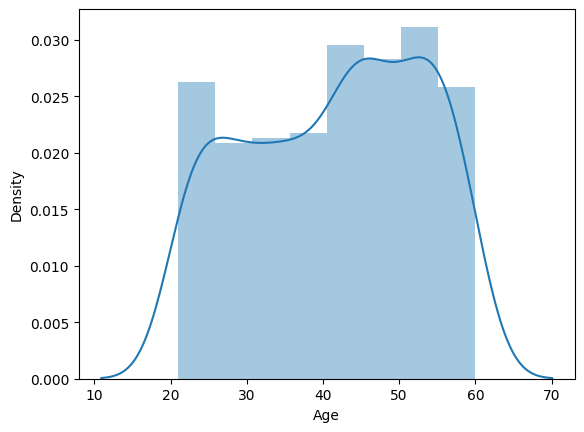

In [15]:
# univariate analysis

import seaborn as sns
import matplotlib.pyplot as plt


sns.distplot(data['Age'])


<Axes: xlabel='Credit_Score', ylabel='Income'>

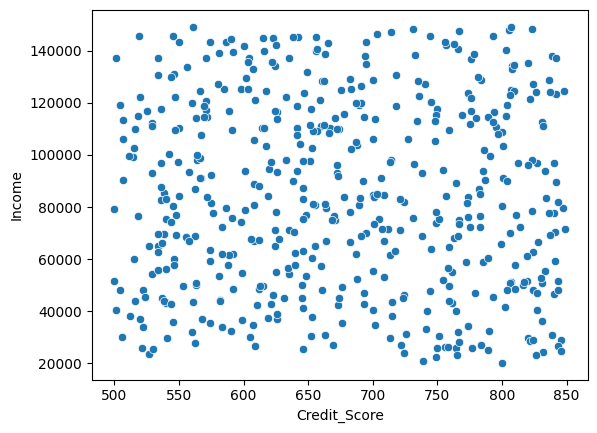

In [16]:
# bivariate analysis

sns.scatterplot(x=data['Credit_Score'],y=data['Income'])

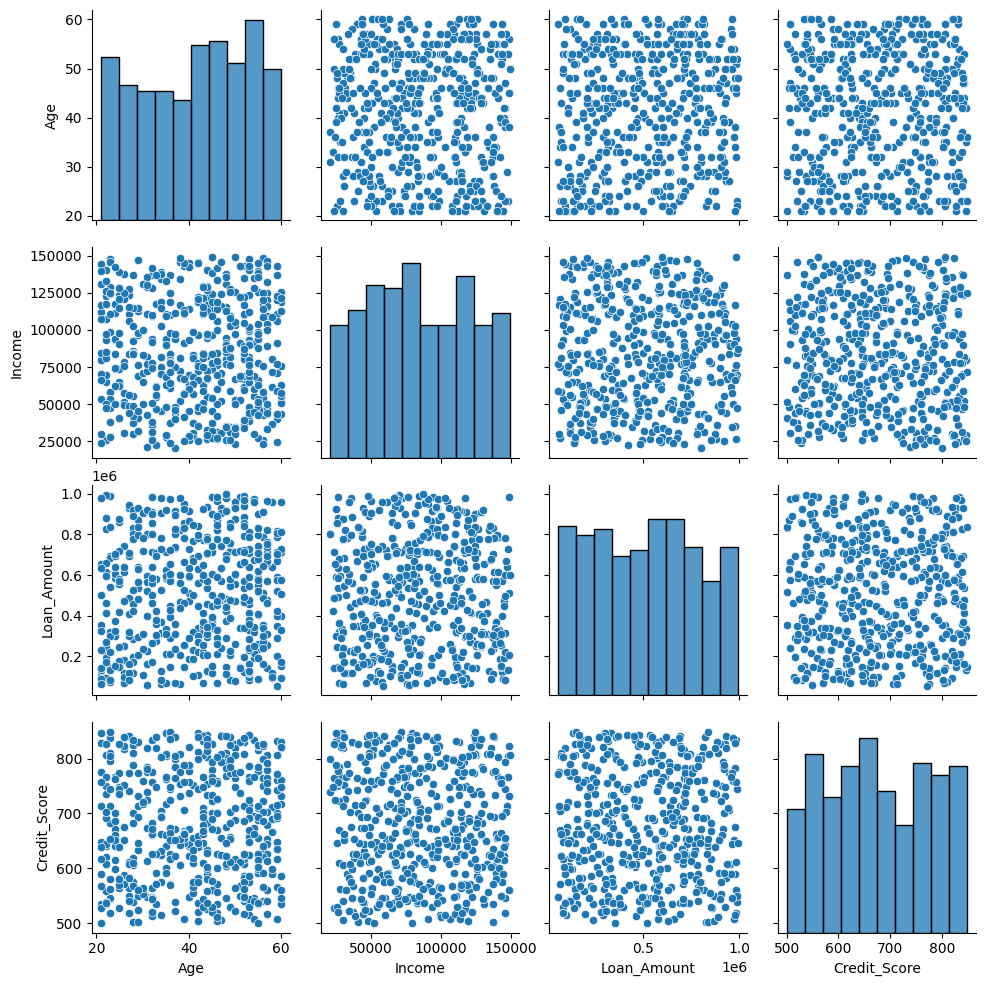

In [17]:
# multivariate analysis

sns.pairplot(data)

# Feature Engineering

# Encoding

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              500 non-null    int64 
 1   Gender           500 non-null    object
 2   Education        500 non-null    object
 3   Employment_Type  500 non-null    object
 4   Income           500 non-null    int64 
 5   Loan_Amount      500 non-null    int64 
 6   Credit_Score     500 non-null    int64 
 7   Credit_Risk      500 non-null    object
 8   Loan_Approved    500 non-null    object
dtypes: int64(4), object(5)
memory usage: 35.3+ KB


In [19]:
data.columns

Index(['Age', 'Gender', 'Education', 'Employment_Type', 'Income',
       'Loan_Amount', 'Credit_Score', 'Credit_Risk', 'Loan_Approved'],
      dtype='object')

In [20]:
# label encoding on target column : Loan_Approved


from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler


le = LabelEncoder()

data['Loan_Approved'] = le.fit_transform(data['Loan_Approved'])
data['Loan_Approved']

0      0
1      1
2      0
3      1
4      0
      ..
495    0
496    0
497    0
498    1
499    0
Name: Loan_Approved, Length: 500, dtype: int64

In [21]:
# ordinal encoding on credit risk
#low  as 0, medium as 1 and high as 2

oe = OrdinalEncoder(categories=[["Low","Medium","High"]])

data['Credit_Risk']= oe.fit_transform(data[['Credit_Risk']])
data['Credit_Risk']

0      1.0
1      0.0
2      1.0
3      2.0
4      0.0
      ... 
495    2.0
496    2.0
497    2.0
498    1.0
499    2.0
Name: Credit_Risk, Length: 500, dtype: float64

In [22]:
# apply  ordinal encoding on education column

oe = OrdinalEncoder(categories=[['12th', 'Graduate', 'Postgraduate']])

data['Education'] = oe.fit_transform(data[['Education']])

In [23]:
data

,Age,Gender,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Loan_Approved
0,59,Male,1.0,Business,110373,674771,616,1.0,0
1,49,Female,2.0,Salaried,103362,573886,801,0.0,1
2,35,Female,0.0,Business,110517,583884,641,1.0,0
3,28,Male,0.0,Salaried,85450,284627,538,2.0,1
4,41,Female,1.0,Self-Employed,30382,681827,751,0.0,0
...,...,...,...,...,...,...,...,...,...
495,32,Female,2.0,Salaried,74341,899710,544,2.0,0
496,29,Male,2.0,Business,32087,629365,560,2.0,0
497,27,Female,1.0,Salaried,43762,162782,582,2.0,0
498,48,Male,2.0,Business,135812,677220,622,1.0,1


In [24]:
 # apply label enoding on employent_type

le = LabelEncoder()
data['Employment_Type'] = le.fit_transform(data['Employment_Type'])
data['Employment_Type']

0      0
1      1
2      0
3      1
4      2
      ..
495    1
496    0
497    1
498    0
499    0
Name: Employment_Type, Length: 500, dtype: int64

In [25]:
data

,Age,Gender,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Loan_Approved
0,59,Male,1.0,0,110373,674771,616,1.0,0
1,49,Female,2.0,1,103362,573886,801,0.0,1
2,35,Female,0.0,0,110517,583884,641,1.0,0
3,28,Male,0.0,1,85450,284627,538,2.0,1
4,41,Female,1.0,2,30382,681827,751,0.0,0
...,...,...,...,...,...,...,...,...,...
495,32,Female,2.0,1,74341,899710,544,2.0,0
496,29,Male,2.0,0,32087,629365,560,2.0,0
497,27,Female,1.0,1,43762,162782,582,2.0,0
498,48,Male,2.0,0,135812,677220,622,1.0,1


In [26]:
# onehot encoding on gender column

data = pd.get_dummies(data,columns=["Gender"])
data

,Age,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Loan_Approved,Gender_Female,Gender_Male
0,59,1.0,0,110373,674771,616,1.0,0,False,True
1,49,2.0,1,103362,573886,801,0.0,1,True,False
2,35,0.0,0,110517,583884,641,1.0,0,True,False
3,28,0.0,1,85450,284627,538,2.0,1,False,True
4,41,1.0,2,30382,681827,751,0.0,0,True,False
...,...,...,...,...,...,...,...,...,...,...
495,32,2.0,1,74341,899710,544,2.0,0,True,False
496,29,2.0,0,32087,629365,560,2.0,0,False,True
497,27,1.0,1,43762,162782,582,2.0,0,True,False
498,48,2.0,0,135812,677220,622,1.0,1,False,True


In [27]:
# feature selection

data.corr()

,Age,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Loan_Approved,Gender_Female,Gender_Male
Age,1.000000,-0.083277,-0.046470,-0.030074,0.092149,0.027804,-0.037432,-0.035791,-0.017365,0.017365
Education,-0.083277,1.000000,0.030514,-0.018700,-0.024805,-0.011932,-0.007219,-0.051207,0.000400,-0.000400
Employment_Type,-0.046470,0.030514,1.000000,0.000706,-0.034589,-0.019286,0.020323,0.026172,0.071954,-0.071954
Income,-0.030074,-0.018700,0.000706,1.000000,-0.015250,-0.030201,0.032490,0.003718,-0.036229,0.036229
Loan_Amount,0.092149,-0.024805,-0.034589,-0.015250,1.000000,0.023578,-0.019842,-0.029524,-0.046795,0.046795
Credit_Score,0.027804,-0.011932,-0.019286,-0.030201,0.023578,1.000000,-0.934687,0.106605,0.001925,-0.001925
Credit_Risk,-0.037432,-0.007219,0.020323,0.032490,-0.019842,-0.934687,1.000000,-0.110624,0.010719,-0.010719
Loan_Approved,-0.035791,-0.051207,0.026172,0.003718,-0.029524,0.106605,-0.110624,1.000000,-0.015521,0.015521
Gender_Female,-0.017365,0.000400,0.071954,-0.036229,-0.046795,0.001925,0.010719,-0.015521,1.000000,-1.000000
Gender_Male,0.017365,-0.000400,-0.071954,0.036229,0.046795,-0.001925,-0.010719,0.015521,-1.000000,1.000000


<Axes: >

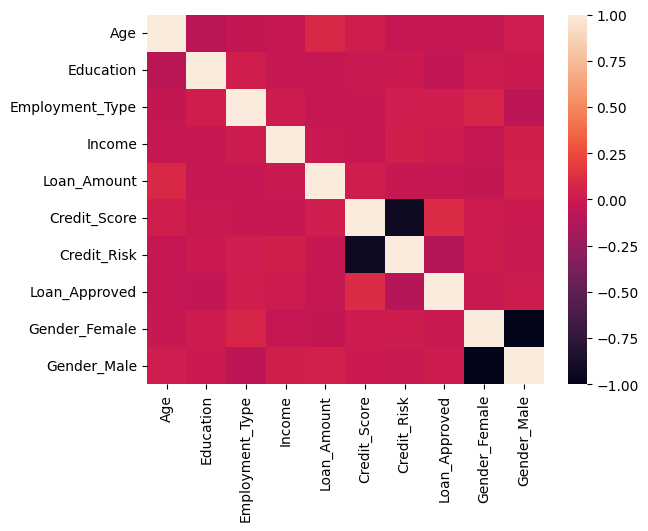

In [28]:
sns.heatmap(data.corr())

In [29]:
# splitting dataset

x = data.drop(columns='Loan_Approved')
y = data['Loan_Approved']

In [30]:
x

,Age,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Gender_Female,Gender_Male
0,59,1.0,0,110373,674771,616,1.0,False,True
1,49,2.0,1,103362,573886,801,0.0,True,False
2,35,0.0,0,110517,583884,641,1.0,True,False
3,28,0.0,1,85450,284627,538,2.0,False,True
4,41,1.0,2,30382,681827,751,0.0,True,False
...,...,...,...,...,...,...,...,...,...
495,32,2.0,1,74341,899710,544,2.0,True,False
496,29,2.0,0,32087,629365,560,2.0,False,True
497,27,1.0,1,43762,162782,582,2.0,True,False
498,48,2.0,0,135812,677220,622,1.0,False,True


In [31]:
y

0      0
1      1
2      0
3      1
4      0
      ..
495    0
496    0
497    0
498    1
499    0
Name: Loan_Approved, Length: 500, dtype: int64

In [32]:
# splitting into training and testing

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [33]:
x_train

,Age,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Gender_Female,Gender_Male
249,40,0.0,1,69230,510385,548,2.0,True,False
433,55,0.0,1,103986,618020,688,1.0,True,False
19,58,2.0,0,80631,638717,689,1.0,False,True
322,60,1.0,1,62600,507382,534,2.0,True,False
332,27,0.0,2,105667,707911,608,1.0,False,True
...,...,...,...,...,...,...,...,...,...
106,47,2.0,0,69841,572220,806,0.0,False,True
270,37,1.0,1,48082,308635,522,2.0,False,True
348,45,1.0,1,36905,350135,520,2.0,False,True
435,53,0.0,2,71612,358449,707,0.0,True,False


# feature scaling

In [34]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# minmax scalar

mm= MinMaxScaler()

x_train[['Income','Credit_Score']] = mm.fit_transform(x_train[['Income','Credit_Score']]) # when we are going to deal with any application, it is going to compute with respect to mean and standard deviation for the given data, whichever the dataset we have given

x_test[['Income','Credit_Score']] = mm.transform(x_test[['Income','Credit_Score']]) # this transform is using previous means and standard deviation 

In [35]:
x_train

,Age,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Gender_Female,Gender_Male
249,40,0.0,1,0.380179,510385,0.138329,2.0,True,False
433,55,0.0,1,0.649474,618020,0.541787,1.0,True,False
19,58,2.0,0,0.468515,638717,0.544669,1.0,False,True
322,60,1.0,1,0.328808,507382,0.097983,2.0,True,False
332,27,0.0,2,0.662498,707911,0.311239,1.0,False,True
...,...,...,...,...,...,...,...,...,...
106,47,2.0,0,0.384913,572220,0.881844,0.0,False,True
270,37,1.0,1,0.216321,308635,0.063401,2.0,False,True
348,45,1.0,1,0.129720,350135,0.057637,2.0,False,True
435,53,0.0,2,0.398635,358449,0.596542,0.0,True,False


In [36]:
# standard scaler

sc = StandardScaler()

x_train[["Age","Loan_Amount"]] = sc.fit_transform(x_train[["Age","Loan_Amount"]])

x_test[["Age","Loan_Amount"]] = sc.transform(x_test[["Age","Loan_Amount"]])

In [37]:
x_train

,Age,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Gender_Female,Gender_Male
249,-0.119370,0.0,1,0.380179,-0.046635,0.138329,2.0,True,False
433,1.171112,0.0,1,0.649474,0.357569,0.541787,1.0,True,False
19,1.429208,2.0,0,0.468515,0.435293,0.544669,1.0,False,True
322,1.601272,1.0,1,0.328808,-0.057913,0.097983,2.0,True,False
332,-1.237787,0.0,2,0.662498,0.695139,0.311239,1.0,False,True
...,...,...,...,...,...,...,...,...,...
106,0.482855,2.0,0,0.384913,0.185575,0.881844,0.0,False,True
270,-0.377466,1.0,1,0.216321,-0.804272,0.063401,2.0,False,True
348,0.310791,1.0,1,0.129720,-0.648426,0.057637,2.0,False,True
435,0.999048,0.0,2,0.398635,-0.617204,0.596542,0.0,True,False


# # Model building

In [38]:
# SVM - classifier

from sklearn.svm import SVC

model = SVC()

model.fit(x_train,y_train)

y_pred = model.predict(x_test)

y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [39]:
# evaluation matrix

from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80        67
           1       0.00      0.00      0.00        33

    accuracy                           0.67       100
   macro avg       0.34      0.50      0.40       100
weighted avg       0.45      0.67      0.54       100



C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Decision Tree

In [122]:
# import decision tree classifier

from sklearn.tree import DecisionTreeClassifier

# gini

dt_model = DecisionTreeClassifier(criterion="gini")

dt_model.fit(x_train,y_train)

dt_pred = dt_model.predict(x_test)

print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.64      0.63      0.63        67
           1       0.26      0.27      0.27        33

    accuracy                           0.51       100
   macro avg       0.45      0.45      0.45       100
weighted avg       0.51      0.51      0.51       100



In [123]:
# entropy

dt_model = DecisionTreeClassifier(criterion="entropy")

dt_model.fit(x_train,y_train)

dt_pred = dt_model.predict(x_test)

print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.73      0.64      0.68        67
           1       0.41      0.52      0.46        33

    accuracy                           0.60       100
   macro avg       0.57      0.58      0.57       100
weighted avg       0.63      0.60      0.61       100



### KNN

In [ ]:
from sklearn.neighbors import  KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(x_train,y_train)

knn_pred = knn_model.predict(x_test)
knn_pred

array([1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0])

In [ ]:
print(classification_report(y_test,knn_pred))

              precision    recall  f1-score   support

           0       0.77      0.76      0.77        67
           1       0.53      0.55      0.54        33

    accuracy                           0.69       100
   macro avg       0.65      0.65      0.65       100
weighted avg       0.69      0.69      0.69       100



### Ensemble Learning

In [ ]:
# bagging

# Random forest

from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(n_estimators= 50,random_state = 42)

rf_model.fit(x_train,y_train)

rf_pred = rf_model.predict(x_test)
rf_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0])

In [ ]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.69      0.88      0.78        67
           1       0.47      0.21      0.29        33

    accuracy                           0.66       100
   macro avg       0.58      0.55      0.53       100
weighted avg       0.62      0.66      0.62       100



In [ ]:
# boosting

from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier

# adaboost : adaptive boosting

ada_model = AdaBoostClassifier(n_estimators = 50,random_state=42)
ada_model.fit(x_train,y_train)
ada_pred = ada_model.predict(x_test)
ada_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
print(classification_report(y_test,ada_pred))

              precision    recall  f1-score   support

           0       0.66      0.97      0.79        67
           1       0.00      0.00      0.00        33

    accuracy                           0.65       100
   macro avg       0.33      0.49      0.39       100
weighted avg       0.44      0.65      0.53       100



In [ ]:
# GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=50,random_state=42)

gb_model.fit(x_train,y_train)

gb_pred = gb_model.predict(x_test)
gb_pred

In [ ]:
print(classification_report(y_test,gb_pred))

              precision    recall  f1-score   support

           0       0.66      0.88      0.75        67
           1       0.20      0.06      0.09        33

    accuracy                           0.61       100
   macro avg       0.43      0.47      0.42       100
weighted avg       0.51      0.61      0.53       100



In [ ]:
!pip install xgboost

In [ ]:
# xgboost

from xgboost import XGBClassifier

xg_model = XGBClassifier(n_estimators = 50,random_state= 42)

xg_model.fit(x_train,y_train)

xg_pred = xg_model.predict(x_test)
xg_pred

In [ ]:
print(classification_report(y_test,xg_pred))

              precision    recall  f1-score   support

           0       0.66      0.81      0.72        67
           1       0.28      0.15      0.20        33

    accuracy                           0.59       100
   macro avg       0.47      0.48      0.46       100
weighted avg       0.53      0.59      0.55       100

